# Analyze JobB — trained-models validation on Deceuninck

Companion to `analyze jobA.ipynb`, but focused on the **JobB** runs that re-evaluate the trained
models against the Deceuninck dataset.

The single Deceuninck category means we cannot compute per-category statistics the way JobA does —
instead we treat each model run as one observation and dig into the per-image score distribution
and the per-defect-type recall to understand model behavior.

Sections:
1. **Setup** — paths, imports.
2. **Loader** — walks the JobB output dirs (baseline + seed sweep) and returns a tidy DataFrame.
   Each row is one `(model, seed)` pair, so multi-seed runs surface as multiple rows per model.
3. **§1 Summary metrics per model** — comparison table, generalization gap, per-defect recall.
4. **§2 Graphical comparison** — accuracy bars, latency-vs-quality Pareto, generalization gap.
5. **§3 Coherence / sanity checks** — flags `0.0` / `1.0` metrics, threshold position relative to
   the actual score distribution, sample-count vs fit-time consistency.
6. **§4 Score distributions** — per-run histogram of test scores split by `good` vs `defect`
   with the calibrated threshold drawn on top.
7. **§5 Confusion matrices** — derived from `predictions_*.json` so the headline F1 can be audited.
8. **§6 JobB vs JobA reference** — quick reuse of `_analysis/compare_jobB_vs_jobA.tsv`.
9. **§7 Multi-seed coherence** — coverage matrix, mean ± std aggregates, threshold stability,
   saturation re-check across seeds.
10. **§8 Engineering suggestions** — what to look at next, framed for the thesis goal.

## 1. Setup

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent

OUTPUTS = REPO / "data" / "outputs"
JOBB_DIR = OUTPUTS / "jobB_val_defect_V1"
JOBB_SEED_DIR = OUTPUTS / "jobB_val_defect_and_seed"
JOBA_DIR = OUTPUTS / "jobA_val_defect_V1"
ANALYSIS_DIR = JOBB_DIR / "_analysis"

JOBB_SOURCES = [d for d in (JOBB_DIR, JOBB_SEED_DIR) if d.is_dir()]
assert JOBB_SOURCES, f"no JobB output dirs found under {OUTPUTS}"
print("REPO         :", REPO)
for d in JOBB_SOURCES:
    print("JOBB source :", d)
print("JOBA         :", JOBA_DIR if JOBA_DIR.is_dir() else "(not present)")

REPO         : C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection
JOBB source : C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\data\outputs\jobB_val_defect_V1
JOBB source : C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\data\outputs\jobB_val_defect_and_seed
JOBA         : C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\data\outputs\jobA_val_defect_V1


## 2. Loader

Each JobB run directory holds a `benchmark_summary.json` whose `models[]` array contains one entry
per model that ran. Some directories bundle 3 models (the Deceuninck mass-eval), others contain a
single model — we just iterate and flatten.

The seed lives in `summary['run']['seed']`; when missing we try to recover it from a `_s<N>_`
fragment in the directory name (added by the seed-sweep driver), falling back to `42` (the original
default). The `source` column records which top-level dir a row came from so multi-seed reruns and
the original baseline are easy to slice apart.

Per-image scores are taken from `predictions_<model>.json` and `validation_predictions_<model>.json`.

In [2]:
_SEED_RE = re.compile(r"_s(\d+)_")


def _extract_seed(run_dir_name: str, summary: dict) -> int:
    seed = summary.get("run", {}).get("seed")
    if seed is not None:
        return int(seed)
    m = _SEED_RE.search(run_dir_name)
    return int(m.group(1)) if m else 42


def load_jobB_runs(*directories: Path) -> pd.DataFrame:
    rows = []
    for directory in directories:
        if not directory.is_dir():
            continue
        for run_dir in sorted(p for p in directory.iterdir() if p.is_dir() and not p.name.startswith("_")):
            summary_path = run_dir / "benchmark_summary.json"
            if not summary_path.is_file():
                continue
            b = json.loads(summary_path.read_text())
            run_meta = {
                "source": directory.name,
                "run_dir": run_dir.name,
                "run_path": str(run_dir),
                "run_id": b.get("run", {}).get("run_id"),
                "seed": _extract_seed(run_dir.name, b),
                "corruption_enabled": b.get("corruption", {}).get("enabled"),
                "corruption_type": b.get("corruption", {}).get("type"),
                "corruption_severity": b.get("corruption", {}).get("severity"),
                "dataset_path": b.get("dataset", {}).get("path"),
                "resize_w": b.get("preprocessing", {}).get("resize", {}).get("width"),
                "resize_h": b.get("preprocessing", {}).get("resize", {}).get("height"),
            }
            for m in b.get("models", []):
                row = {**run_meta}
                row.update({k: v for k, v in m.items() if k not in {"model_cfg", "per_defect_recall", "per_defect_support"}})
                row["per_defect_recall"] = m.get("per_defect_recall", {})
                row["per_defect_support"] = m.get("per_defect_support", {})
                rows.append(row)
    return pd.DataFrame(rows)


def load_predictions(run_path: str | Path, model: str, validation: bool = False) -> pd.DataFrame:
    fname = ("validation_predictions_" if validation else "predictions_") + f"{model}.json"
    path = Path(run_path) / fname
    if not path.is_file():
        return pd.DataFrame()
    return pd.DataFrame(json.loads(path.read_text()))


df = load_jobB_runs(*JOBB_SOURCES)
print(f"Loaded {len(df)} model rows from {df['run_dir'].nunique()} run directories"
      f" across {df['source'].nunique()} source dirs.")
df[["source", "run_dir", "model", "seed", "train_samples", "val_samples", "test_samples"]]

Loaded 13 model rows from 11 run directories across 2 source dirs.


,source,run_dir,model,seed,train_samples,val_samples,test_samples
0,jobB_val_defect_V1,jobB_anomalib_draem_20260428_085806,anomalib_draem,42,161,67,478
1,jobB_val_defect_V1,jobB_anomalib_stfpm_20260427_231116,anomalib_stfpm,42,161,67,478
2,jobB_val_defect_V1,jobB_rd4ad_20260428_072729,rd4ad,42,161,67,478
3,jobB_val_defect_V1,jobB_val_defect_deceuninck_20260427_102501,anomalib_patchcore,42,161,67,478
4,jobB_val_defect_V1,jobB_val_defect_deceuninck_20260427_102501,anomalib_padim,42,161,67,478
5,jobB_val_defect_V1,jobB_val_defect_deceuninck_20260427_102501,subspacead,42,161,67,478
6,jobB_val_defect_and_seed,jobB_val_defect_deceuninck_anomalib_padim_s123...,anomalib_padim,123,161,67,478
7,jobB_val_defect_and_seed,jobB_val_defect_deceuninck_anomalib_padim_s17_...,anomalib_padim,17,161,67,478
8,jobB_val_defect_and_seed,jobB_val_defect_deceuninck_anomalib_padim_s7_2...,anomalib_padim,7,161,67,478
9,jobB_val_defect_and_seed,jobB_val_defect_deceuninck_anomalib_patchcore_...,anomalib_patchcore,7,161,67,478


## §1 Summary metrics per model

Headline numbers, one row per model. The `_industrial` block (recall@1pct FPR / recall@5pct FPR /
macro_recall) is the metric set the thesis uses for the rolling-window industrial benchmark.

In [3]:
headline_cols = [
    "model", "seed",
    "train_samples", "val_samples", "test_samples",
    "auroc", "aupr", "f1", "precision", "recall", "accuracy",
    "recall_at_fpr_1pct", "recall_at_fpr_5pct", "macro_recall", "weighted_recall",
    "threshold_mode", "threshold_used",
    "fit_seconds", "predict_seconds", "ms_per_image", "fps", "peak_vram_mb",
]
summary = df[headline_cols].copy()
summary = summary.sort_values(["model", "seed"]).reset_index(drop=True)
summary.round(4)

,model,seed,train_samples,val_samples,test_samples,auroc,aupr,f1,precision,recall,...,recall_at_fpr_5pct,macro_recall,weighted_recall,threshold_mode,threshold_used,fit_seconds,predict_seconds,ms_per_image,fps,peak_vram_mb
0,anomalib_draem,42,161,67,478,0.8016,0.9705,0.9653,0.9370,0.9954,...,0.3210,0.9989,0.9954,val_f1,0.9896,2861.0278,17.9171,37.4835,26.6784,79980.318
1,anomalib_padim,7,161,67,478,1.0000,1.0000,0.9641,1.0000,0.9307,...,1.0000,0.9610,0.9307,val_f1,76.4674,19.3987,6.6943,14.0047,71.4045,4203.002
2,anomalib_padim,17,161,67,478,0.9926,0.9992,0.9860,0.9953,0.9769,...,1.0000,0.9831,0.9769,val_f1,72.1431,13.6051,6.6507,13.9135,71.8727,4203.002
3,anomalib_padim,42,161,67,478,0.9999,1.0000,0.9977,1.0000,0.9954,...,1.0000,0.9770,0.9954,val_f1,70.0831,11.6471,9.6683,20.2265,49.4400,4202.877
4,anomalib_padim,123,161,67,478,0.9998,1.0000,0.9965,1.0000,0.9931,...,1.0000,0.9781,0.9931,val_f1,64.2371,13.8046,6.7641,14.1509,70.6667,4203.002
5,anomalib_patchcore,7,161,67,478,1.0000,1.0000,0.9895,1.0000,0.9792,...,1.0000,0.9352,0.9792,val_f1,39.5715,92.7311,15.9377,33.3425,29.9918,12430.021
6,anomalib_patchcore,42,161,67,478,1.0000,1.0000,1.0000,1.0000,1.0000,...,1.0000,1.0000,1.0000,val_f1,37.6074,762.7088,159.7645,334.2353,2.9919,12430.021
7,anomalib_stfpm,42,161,67,478,0.8923,0.9874,0.9080,0.9686,0.8545,...,0.6397,0.9373,0.8545,val_f1,0.0192,446.4042,6.6905,13.9968,71.4449,3111.561
8,rd4ad,42,161,67,478,1.0000,1.0000,0.9824,1.0000,0.9654,...,1.0000,0.9915,0.9654,val_f1,0.0020,1987.7145,12.1509,25.4204,39.3386,19563.863
9,subspacead,7,161,67,478,1.0000,1.0000,0.9654,1.0000,0.9330,...,1.0000,0.9835,0.9330,val_f1,6.7551,52.1879,73.7322,154.2515,6.4829,1919.191


In [4]:
# val (calibration) vs test (held-out) — generalization gap, per (model, seed).
gap_cols = ["model", "seed", "val_f1", "f1", "val_auroc", "auroc", "val_aupr", "aupr", "val_recall", "recall", "val_precision", "precision"]
gap = df[gap_cols].copy()
for m in ["f1", "auroc", "aupr", "recall", "precision"]:
    gap[f"{m}_gap"] = gap[m] - gap[f"val_{m}"]
gap.sort_values(["model", "seed"]).set_index(["model", "seed"]).round(4)

val_f1      f1  val_auroc   auroc  val_aupr    aupr  \
model              seed                                                        
anomalib_draem     42    0.8991  0.9653     0.8707  0.8016    0.9476  0.9705   
anomalib_padim     7     1.0000  0.9641     1.0000  1.0000    1.0000  1.0000   
                   17    1.0000  0.9860     1.0000  0.9926    1.0000  0.9992   
                   42    1.0000  0.9977     1.0000  0.9999    1.0000  1.0000   
                   123   1.0000  0.9965     1.0000  0.9998    1.0000  1.0000   
anomalib_patchcore 7     1.0000  0.9895     1.0000  1.0000    1.0000  1.0000   
                   42    1.0000  1.0000     1.0000  1.0000    1.0000  1.0000   
anomalib_stfpm     42    0.9072  0.9080     0.9206  0.8923    0.9715  0.9874   
rd4ad              42    1.0000  0.9824     1.0000  1.0000    1.0000  1.0000   
subspacead         7     1.0000  0.9654     1.0000  1.0000    1.0000  1.0000   
                   17    1.0000  0.9859     1.0000  1.0000    1.0000  1.0000   
                   42    1.0000  0.9988     1.0000  1.0000    1.0000  1.0000   
                   123   1.0000  0.9930     1.0000  1.0000    1.0000  1.0000   

                         val_recall  recall  val_precision  precision  f1_gap  \
model              seed                                                         
anomalib_draem     42         1.000  0.9954         0.8167     0.9370  0.0662   
anomalib_padim     7          1.000  0.9307         1.0000     1.0000 -0.0359   
                   17         1.000  0.9769         1.0000     0.9953 -0.0140   
                   42         1.000  0.9954         1.0000     1.0000 -0.0023   
                   123        1.000  0.9931         1.0000     1.0000 -0.0035   
anomalib_patchcore 7          1.000  0.9792         1.0000     1.0000 -0.0105   
                   42         1.000  1.0000         1.0000     1.0000  0.0000   
anomalib_stfpm     42         0.898  0.8545         0.9167     0.9686  0.0008   
rd4ad              42         1.000  0.9654         1.0000     1.0000 -0.0176   
subspacead         7          1.000  0.9330         1.0000     1.0000 -0.0346   
                   17         1.000  0.9723         1.0000     1.0000 -0.0141   
                   42         1.000  0.9977         1.0000     1.0000 -0.0012   
                   123        1.000  0.9861         1.0000     1.0000 -0.0070   

                         auroc_gap  aupr_gap  recall_gap  precision_gap  
model              seed                                                  
anomalib_draem     42      -0.0691    0.0229     -0.0046         0.1203  
anomalib_padim     7        0.0000    0.0000     -0.0693         0.0000  
                   17      -0.0074   -0.0008     -0.0231        -0.0047  
                   42      -0.0001   -0.0000     -0.0046         0.0000  
                   123     -0.0002   -0.0000     -0.0069         0.0000  
anomalib_patchcore 7        0.0000    0.0000     -0.0208         0.0000  
                   42       0.0000    0.0000      0.0000         0.0000  
anomalib_stfpm     42      -0.0283    0.0159     -0.0435         0.0519  
rd4ad              42       0.0000    0.0000     -0.0346         0.0000  
subspacead         7        0.0000    0.0000     -0.0670         0.0000  
                   17       0.0000    0.0000     -0.0277         0.0000  
                   42       0.0000    0.0000     -0.0023         0.0000  
                   123      0.0000    0.0000     -0.0139         0.0000

In [5]:
# Per-defect-type recall — one row per (model, seed).
all_defects = sorted({d for r in df["per_defect_recall"] for d in r})
rows = []
for _, r in df.iterrows():
    rec = {"model": r["model"], "seed": r["seed"]}
    for d in all_defects:
        rec[d] = r["per_defect_recall"].get(d, np.nan)
    rows.append(rec)
per_defect_df = pd.DataFrame(rows).sort_values(["model", "seed"]).set_index(["model", "seed"]).round(4)
per_defect_df

Black spots  Cleaning felt  Degassing  Pigment spill  \
model              seed                                                         
anomalib_draem     42         1.0000         1.0000        1.0         1.0000   
anomalib_padim     7          0.9375         1.0000        1.0         0.9474   
                   17         0.9412         1.0000        1.0         1.0000   
                   42         0.9375         1.0000        1.0         0.9474   
                   123        0.9412         1.0000        1.0         0.9524   
anomalib_patchcore 7          0.6875         1.0000        1.0         1.0000   
                   42         1.0000         1.0000        1.0         1.0000   
anomalib_stfpm     42         1.0000         0.9091        1.0         0.9474   
rd4ad              42         1.0000         1.0000        1.0         1.0000   
subspacead         7          1.0000         1.0000        1.0         1.0000   
                   17         1.0000         1.0000        1.0         1.0000   
                   42         1.0000         1.0000        1.0         1.0000   
                   123        1.0000         1.0000        1.0         1.0000   

                         Scratch in extrusion direction  
model              seed                                  
anomalib_draem     42                            0.9943  
anomalib_padim     7                             0.9202  
                   17                            0.9742  
                   42                            1.0000  
                   123                           0.9972  
anomalib_patchcore 7                             0.9886  
                   42                            1.0000  
anomalib_stfpm     42                            0.8300  
rd4ad              42                            0.9575  
subspacead         7                             0.9174  
                   17                            0.9656  
                   42                            0.9972  
                   123                           0.9829

In [6]:
# Per-defect support — same for every model in JobB (single dataset), so we show it once.
support = next(iter(df["per_defect_support"]), {})
support_df = pd.DataFrame({"defect": list(support), "n_test_samples": list(support.values())}).sort_values("n_test_samples", ascending=False)
support_df

,defect,n_test_samples
0,Scratch in extrusion direction,353
1,Degassing,23
3,Cleaning felt,22
4,Pigment spill,19
2,Black spots,16


## §2 Graphical comparison

Three views: a metric grid, a latency-vs-F1 Pareto, and the val→test generalization gap.

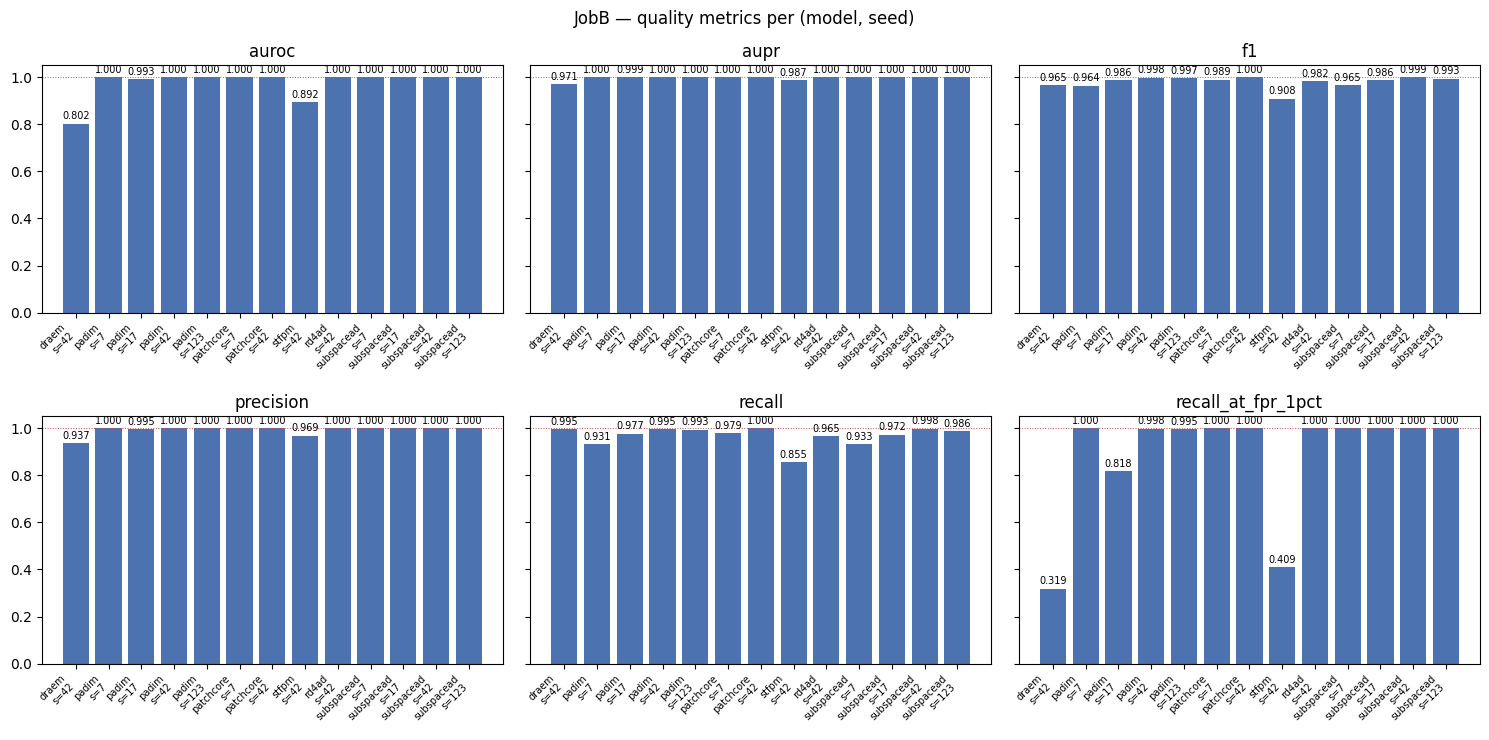

In [7]:
# One bar per (model, seed). Models with one seed show a single bar; multi-seed models
# show one bar per seed so cross-seed variance is visible at a glance.
metrics = ["auroc", "aupr", "f1", "precision", "recall", "recall_at_fpr_1pct"]
df_plot = df.sort_values(["model", "seed"]).reset_index(drop=True)
labels = [f"{m.replace('anomalib_', '')}\ns={s}" for m, s in zip(df_plot["model"], df_plot["seed"])]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), sharey=True)
for ax, metric in zip(axes.ravel(), metrics):
    vals = df_plot[metric].values
    bars = ax.bar(range(len(vals)), vals, color="#4C72B0")
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.axhline(1.0, color="#c44e52", lw=0.7, ls=":")
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=7)
fig.suptitle("JobB — quality metrics per (model, seed)", fontsize=12)
fig.tight_layout()
plt.show()

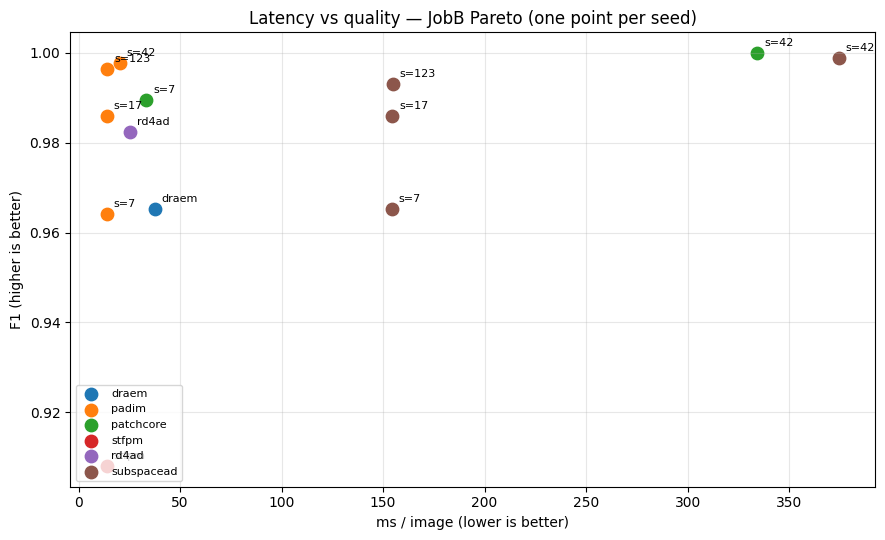

In [8]:
# Pareto: latency vs F1, one point per (model, seed). Point colour by model,
# annotation shows seed when there are multiple per model.
fig, ax = plt.subplots(figsize=(9, 5.5))
models = sorted(df["model"].unique())
cmap = plt.get_cmap("tab10")
color_by = {m: cmap(i % 10) for i, m in enumerate(models)}
for m in models:
    sub = df[df["model"] == m]
    ax.scatter(sub["ms_per_image"], sub["f1"], s=80, color=color_by[m], label=m.replace("anomalib_", ""))
    multi = len(sub) > 1
    for _, r in sub.iterrows():
        tag = f"s={r['seed']}" if multi else r["model"].replace("anomalib_", "")
        ax.annotate(tag, (r["ms_per_image"], r["f1"]),
                    xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.set_xlabel("ms / image (lower is better)")
ax.set_ylabel("F1 (higher is better)")
ax.set_title("Latency vs quality — JobB Pareto (one point per seed)")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

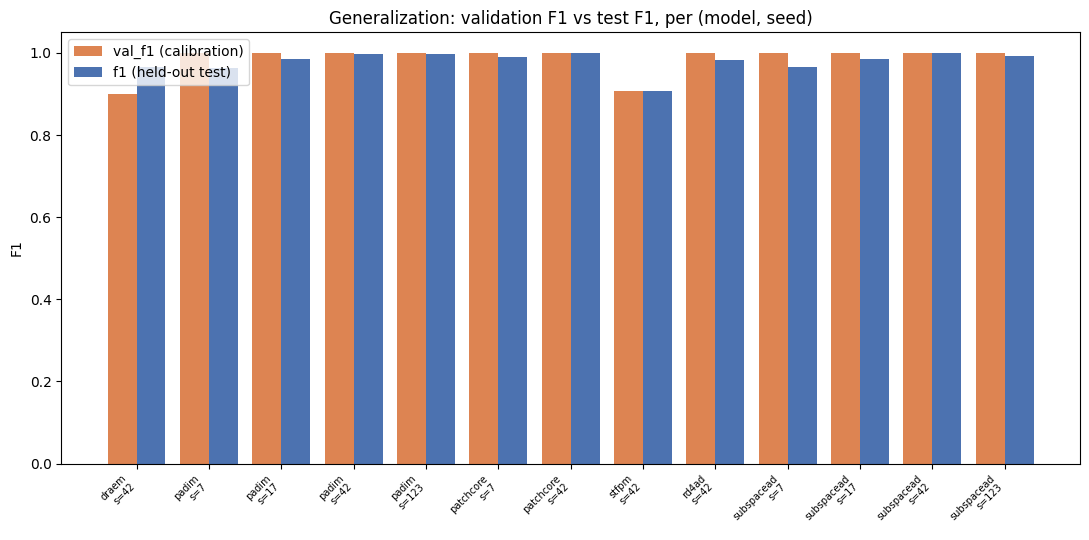

In [9]:
# Generalization gap per (model, seed). When val_f1 saturates at 1.0 across all seeds
# (as on Deceuninck) the val→test gap is the meaningful number, not val_f1 itself.
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(df_plot))
w = 0.4
ax.bar(x - w/2, df_plot["val_f1"].values, w, label="val_f1 (calibration)", color="#dd8452")
ax.bar(x + w/2, df_plot["f1"].values, w, label="f1 (held-out test)", color="#4C72B0")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
ax.set_ylim(0, 1.05)
ax.set_ylabel("F1")
ax.set_title("Generalization: validation F1 vs test F1, per (model, seed)")
ax.legend()
plt.tight_layout()
plt.show()

## §3 Coherence / sanity checks

Goal: surface anything that *should* be a decimal but landed exactly on `0.0` or `1.0`, plus a few
consistency checks between reported numbers and the underlying samples.

Why it matters: with only 478 test images, a single small bug (e.g. all scores collapsing to one
value, or threshold falling outside the score range) can produce "perfect" metrics that do not
reflect real performance.

In [10]:
# 3.1 — flag suspiciously round metric values, per (model, seed)
watch = ["auroc", "aupr", "f1", "precision", "recall",
         "val_auroc", "val_f1", "val_precision", "val_recall",
         "recall_at_fpr_1pct", "recall_at_fpr_5pct",
         "macro_recall", "weighted_recall", "accuracy"]
flags = []
EPS = 1e-9
for _, r in df.iterrows():
    for col in watch:
        v = r.get(col)
        if v is None or pd.isna(v):
            continue
        if abs(v - 1.0) < EPS:
            flags.append({"model": r["model"], "seed": r["seed"], "metric": col, "value": v, "note": "== 1.0 exactly"})
        elif abs(v) < EPS:
            flags.append({"model": r["model"], "seed": r["seed"], "metric": col, "value": v, "note": "== 0.0 exactly"})
        elif v > 0.9999 and v < 1.0:
            flags.append({"model": r["model"], "seed": r["seed"], "metric": col, "value": v, "note": "> 0.9999 (effectively saturated)"})
flag_df = pd.DataFrame(flags)
if flag_df.empty:
    print("No saturated metrics — all values are intermediate decimals.")
else:
    print(f"{len(flag_df)} saturated metric values:")
    display(flag_df.sort_values(["model", "seed", "metric"]).reset_index(drop=True))

98 saturated metric values:


,model,seed,metric,value,note
0,anomalib_draem,42,val_recall,1.0,== 1.0 exactly
1,anomalib_padim,7,aupr,1.0,== 1.0 exactly
2,anomalib_padim,7,auroc,1.0,== 1.0 exactly
3,anomalib_padim,7,precision,1.0,== 1.0 exactly
4,anomalib_padim,7,recall_at_fpr_1pct,1.0,== 1.0 exactly
...,...,...,...,...,...
93,subspacead,123,recall_at_fpr_5pct,1.0,== 1.0 exactly
94,subspacead,123,val_auroc,1.0,== 1.0 exactly
95,subspacead,123,val_f1,1.0,== 1.0 exactly
96,subspacead,123,val_precision,1.0,== 1.0 exactly


In [11]:
# 3.2 — sample-count and time consistency.
# train_samples + val_samples + test_samples should match across models on the SAME dataset run.
consistency = df.groupby("dataset_path")[["train_samples", "val_samples", "test_samples"]].agg(["min", "max"])
consistency

train_samples      val_samples  \
                                                        min  max         min   
dataset_path                                                                   
/content/work/jobB_trained_deceuninck                   161  161          67   
/content/work/jobB_val_defect_deceuninck                161  161          67   
/content/work/jobB_val_defect_deceuninck_s123           161  161          67   
/content/work/jobB_val_defect_deceuninck_s17            161  161          67   
/content/work/jobB_val_defect_deceuninck_s7             161  161          67   

                                                  test_samples       
                                              max          min  max  
dataset_path                                                         
/content/work/jobB_trained_deceuninck          67          478  478  
/content/work/jobB_val_defect_deceuninck       67          478  478  
/content/work/jobB_val_defect_deceuninck_s123  67          478  478  
/content/work/jobB_val_defect_deceuninck_s17   67          478  478  
/content/work/jobB_val_defect_deceuninck_s7    67          478  478

In [12]:
# 3.3 — does the calibrated threshold sit inside the actual score range on val and test?
rows = []
for _, r in df.iterrows():
    test = load_predictions(r["run_path"], r["model"], validation=False)
    val = load_predictions(r["run_path"], r["model"], validation=True)
    if test.empty:
        continue
    rows.append({
        "model": r["model"],
        "seed": r["seed"],
        "threshold": r["threshold_used"],
        "val_score_min": val["score"].min() if not val.empty else None,
        "val_score_max": val["score"].max() if not val.empty else None,
        "val_score_unique": val["score"].nunique() if not val.empty else None,
        "test_score_min": test["score"].min(),
        "test_score_median": test["score"].median(),
        "test_score_max": test["score"].max(),
        "test_score_unique": test["score"].nunique(),
        "frac_test_above_thr": (test["score"] > r["threshold_used"]).mean(),
    })
score_range = pd.DataFrame(rows).sort_values(["model", "seed"]).set_index(["model", "seed"]).round(6)
score_range

threshold  val_score_min  val_score_max  \
model              seed                                            
anomalib_draem     42     0.989597       0.989418       0.999999   
anomalib_padim     7     76.467377      11.669291     234.269272   
                   17    72.143135      13.857672     192.583786   
                   42    70.083054      12.526299     180.340836   
                   123   64.237122      12.242686     173.475128   
anomalib_patchcore 7     39.571541      17.691854      59.260677   
                   42    37.607372      18.098227      63.422756   
anomalib_stfpm     42     0.019215       0.018393       0.046031   
rd4ad              42     0.002050       0.000056       0.022906   
subspacead         7      6.755060       2.197744      18.582680   
                   17     6.759903       2.317878      23.082546   
                   42     6.612747       2.441701      23.611210   
                   123    6.697903       2.381605      22.113504   

                         val_score_unique  test_score_min  test_score_median  \
model              seed                                                        
anomalib_draem     42                  61        0.989313           0.990083   
anomalib_padim     7                   67       12.280343          82.973244   
                   17                  67       12.112884          81.276608   
                   42                  67       12.099661         101.783691   
                   123                 67       11.942915          74.717613   
anomalib_patchcore 7                   67       17.344814          42.060614   
                   42                  67       17.687716          42.227772   
anomalib_stfpm     42                  67        0.018425           0.019837   
rd4ad              42                  67        0.000047           0.002971   
subspacead         7                   67        2.327139           7.639671   
                   17                  67        2.184431           7.687775   
                   42                  67        2.260501           7.688532   
                   123                 67        2.206519           7.719662   

                         test_score_max  test_score_unique  \
model              seed                                      
anomalib_draem     42          1.000000                383   
anomalib_padim     7         229.457367                478   
                   17        189.198318                478   
                   42        204.740967                478   
                   123       179.188934                478   
anomalib_patchcore 7          65.768730                478   
                   42         65.789200                478   
anomalib_stfpm     42          0.065060                478   
rd4ad              42          0.024883                478   
subspacead         7          23.535376                478   
                   17         23.451204                478   
                   42         23.525043                478   
                   123        23.565086                478   

                         frac_test_above_thr  
model              seed                       
anomalib_draem     42               0.962343  
anomalib_padim     7                0.843096  
                   17               0.889121  
                   42               0.901674  
                   123              0.899582  
anomalib_patchcore 7                0.887029  
                   42               0.905858  
anomalib_stfpm     42               0.799163  
rd4ad              42               0.874477  
subspacead         7                0.845188  
                   17               0.880753  
                   42               0.903766  
                   123              0.893305

In [13]:
# 3.4 — class balance per (model, seed). Same dataset and split rules → all rows
# should match within a seed; cross-seed differences here would mean the splitter is
# allocating different test sets per seed, which is the expected behaviour for
# stratify=True + different RNG.
rows = []
for _, r in df.iterrows():
    test = load_predictions(r["run_path"], r["model"])
    if test.empty:
        continue
    rows.append({
        "model": r["model"],
        "seed": r["seed"],
        "n_test": len(test),
        "n_good": int((test["label"] == 0).sum()),
        "n_defect": int((test["label"] == 1).sum()),
        "defect_rate": float((test["label"] == 1).mean()),
    })
pd.DataFrame(rows).sort_values(["model", "seed"]).set_index(["model", "seed"]).round(4)

n_test  n_good  n_defect  defect_rate
model              seed                                       
anomalib_draem     42       478      45       433       0.9059
anomalib_padim     7        478      45       433       0.9059
                   17       478      45       433       0.9059
                   42       478      45       433       0.9059
                   123      478      45       433       0.9059
anomalib_patchcore 7        478      45       433       0.9059
                   42       478      45       433       0.9059
anomalib_stfpm     42       478      45       433       0.9059
rd4ad              42       478      45       433       0.9059
subspacead         7        478      45       433       0.9059
                   17       478      45       433       0.9059
                   42       478      45       433       0.9059
                   123      478      45       433       0.9059

In [14]:
# 3.5 — fit-time vs sample-count plausibility, per (model, seed).
(df[["model", "seed", "train_samples", "fit_seconds", "predict_seconds", "ms_per_image"]]
   .assign(seconds_per_train_sample=lambda x: x["fit_seconds"] / x["train_samples"])
   .round(2)
   .sort_values(["model", "seed"]))

,model,seed,train_samples,fit_seconds,predict_seconds,ms_per_image,seconds_per_train_sample
0,anomalib_draem,42,161,2861.03,17.92,37.48,17.77
8,anomalib_padim,7,161,19.40,6.69,14.00,0.12
7,anomalib_padim,17,161,13.61,6.65,13.91,0.08
4,anomalib_padim,42,161,11.65,9.67,20.23,0.07
6,anomalib_padim,123,161,13.80,6.76,14.15,0.09
9,anomalib_patchcore,7,161,92.73,15.94,33.34,0.58
3,anomalib_patchcore,42,161,762.71,159.76,334.24,4.74
1,anomalib_stfpm,42,161,446.40,6.69,14.00,2.77
2,rd4ad,42,161,1987.71,12.15,25.42,12.35
12,subspacead,7,161,52.19,73.73,154.25,0.32


**How to read §3:**

- A `1.0000` AUROC on 478 images is not impossible but it should always be cross-checked against
  the score histogram in §4 — perfect separability looks like two non-overlapping clusters.
- A threshold that sits *outside* the validation score range, or where `frac_test_above_thr` is
  close to `0` or `1`, means the calibration step was effectively a no-op (everything ends up
  predicted as one class).
- `test_score_unique` close to `1–2` is a hard fail: scores collapsed and the model is constant.
- For the seconds-per-sample column, models with comparable architectures should land in the same
  order of magnitude; an outlier signals a config drift between runs.

## §4 Score distributions

One subplot per model, log-scale y to make the rare-class tail visible. Vertical line is the
calibrated threshold; bars to its right are predicted as *anomaly*.

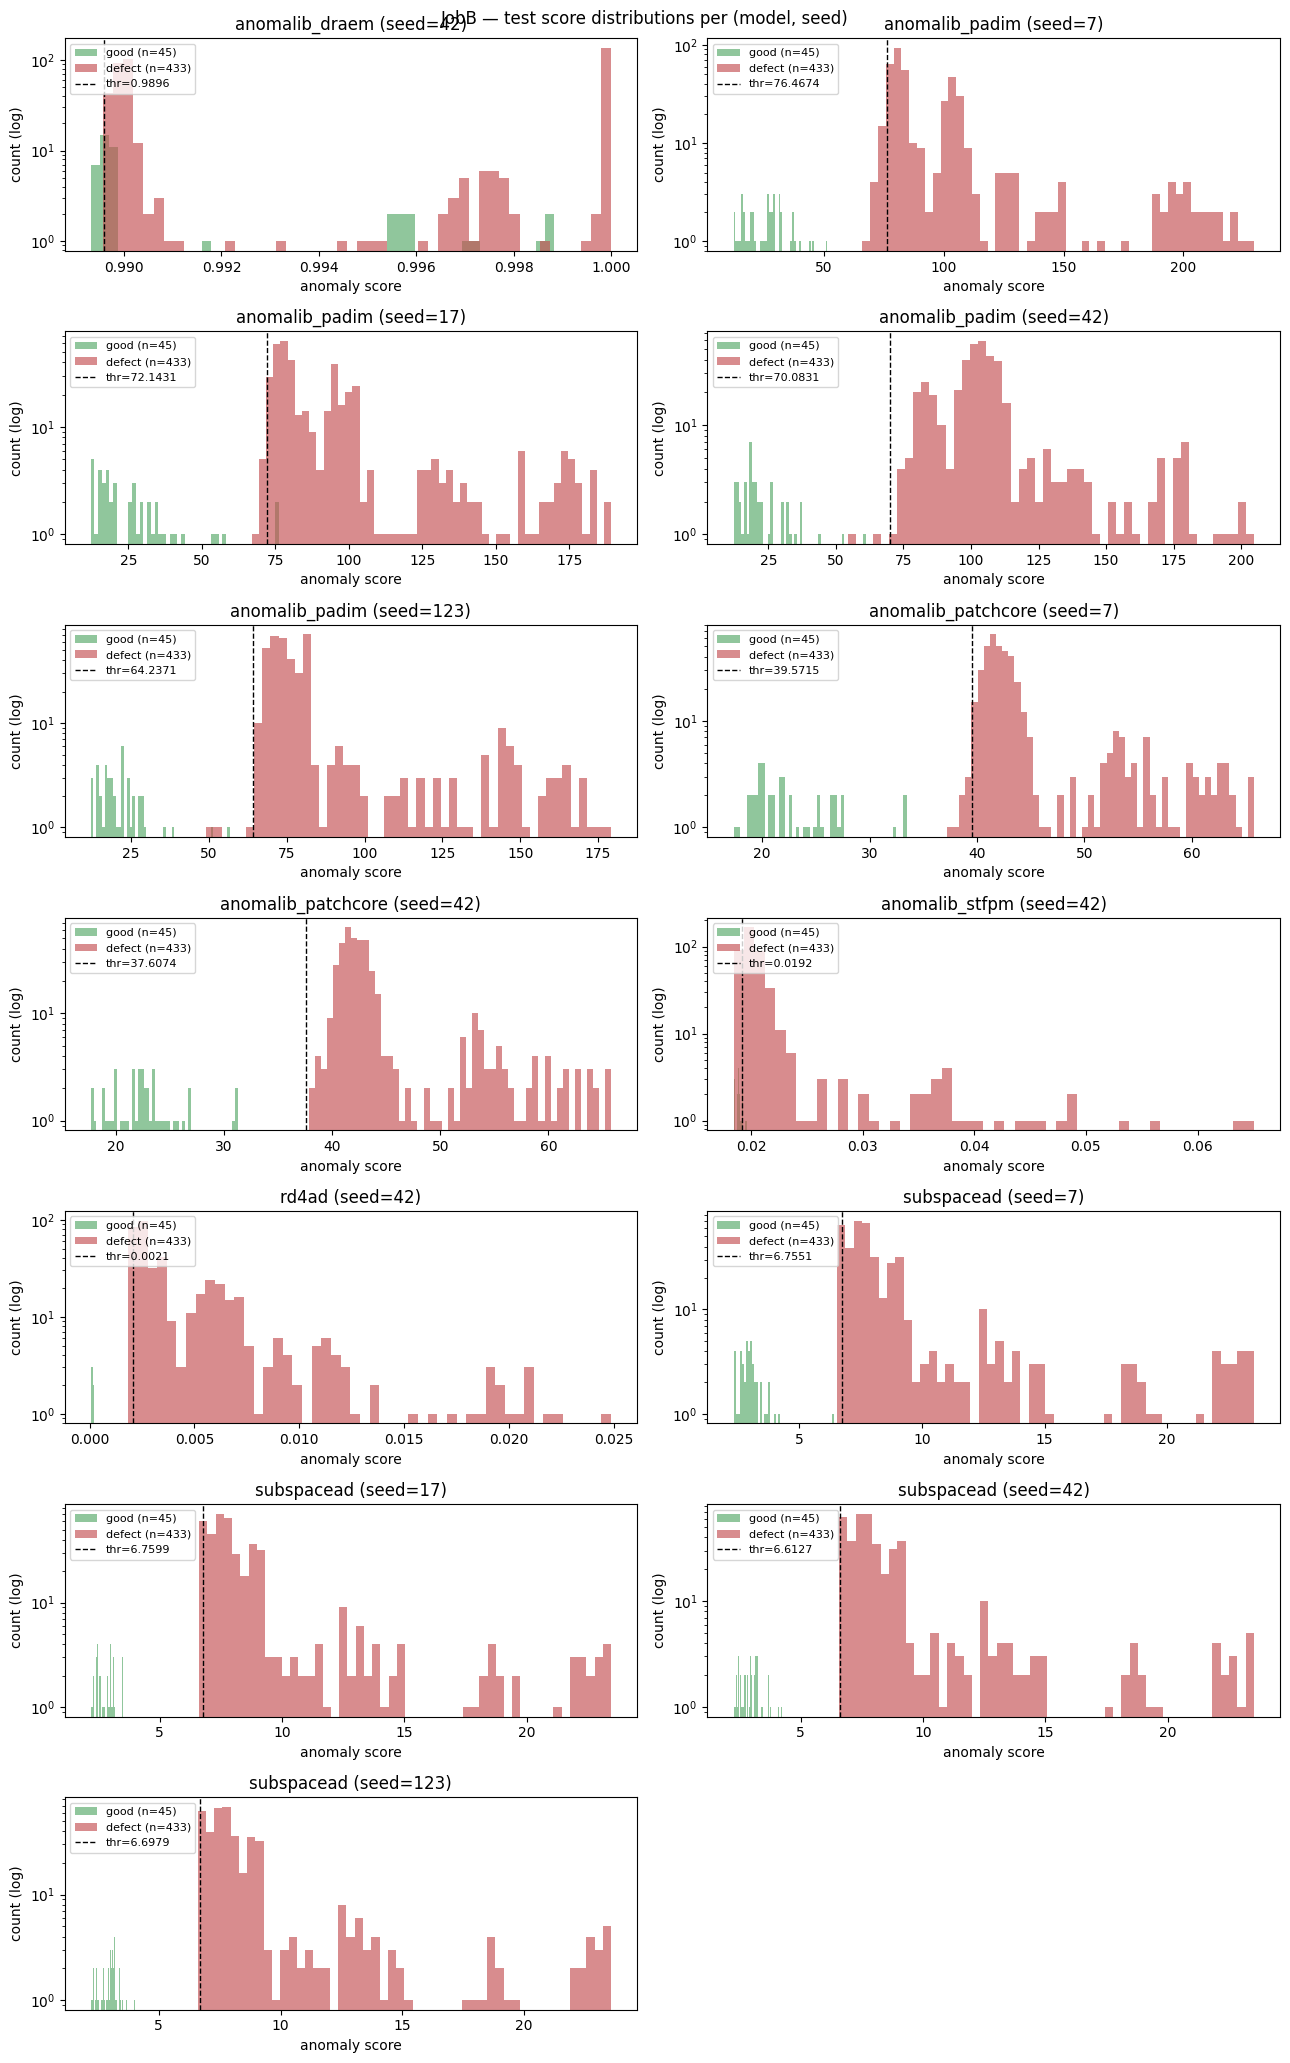

In [15]:
# Score histograms — to keep the grid manageable across many seeds we show one
# histogram per (model, seed) but use the seed=42 baseline as the canonical row when
# present, and only add extra seeds for models that have multi-seed coverage.
df_hist = df.sort_values(["model", "seed"]).reset_index(drop=True)
n = len(df_hist)
ncols = 2
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.0 * nrows))
axes = np.array(axes).reshape(nrows, ncols)
for ax, (_, r) in zip(axes.ravel(), df_hist.iterrows()):
    test = load_predictions(r["run_path"], r["model"])
    if test.empty:
        ax.set_visible(False)
        continue
    good_scores = test.loc[test["label"] == 0, "score"]
    bad_scores = test.loc[test["label"] == 1, "score"]
    bins = 50
    ax.hist(good_scores, bins=bins, alpha=0.65, label=f"good (n={len(good_scores)})", color="#55a868")
    ax.hist(bad_scores, bins=bins, alpha=0.65, label=f"defect (n={len(bad_scores)})", color="#c44e52")
    ax.axvline(r["threshold_used"], color="black", ls="--", lw=1, label=f"thr={r['threshold_used']:.4f}")
    ax.set_yscale("log")
    ax.set_title(f"{r['model']} (seed={r['seed']})")
    ax.set_xlabel("anomaly score")
    ax.set_ylabel("count (log)")
    ax.legend(fontsize=8, loc="upper left")
for ax in axes.ravel()[len(df_hist):]:
    ax.set_visible(False)
fig.suptitle("JobB — test score distributions per (model, seed)", fontsize=12)
fig.tight_layout()
plt.show()

## §5 Confusion matrices

Recomputed from `predictions_*.json` so the headline F1 in §1 can be audited end-to-end.

In [16]:
def confusion(test_df: pd.DataFrame) -> pd.DataFrame:
    cm = pd.crosstab(
        test_df["label"].map({0: "good", 1: "defect"}),
        test_df["pred_is_anomaly"].map({0: "pred_good", 1: "pred_defect"}),
        rownames=["actual"], colnames=["predicted"], dropna=False,
    )
    for col in ["pred_good", "pred_defect"]:
        if col not in cm.columns:
            cm[col] = 0
    for row in ["good", "defect"]:
        if row not in cm.index:
            cm.loc[row] = 0
    return cm.loc[["good", "defect"], ["pred_good", "pred_defect"]]

for _, r in df.sort_values(["model", "seed"]).iterrows():
    test = load_predictions(r["run_path"], r["model"])
    if test.empty:
        continue
    cm = confusion(test)
    tp = cm.loc["defect", "pred_defect"]
    fp = cm.loc["good", "pred_defect"]
    fn = cm.loc["defect", "pred_good"]
    tn = cm.loc["good", "pred_good"]
    prec = tp / (tp + fp) if (tp + fp) else float("nan")
    rec = tp / (tp + fn) if (tp + fn) else float("nan")
    print(f"=== {r['model']} (seed={r['seed']}) ===")
    print(cm.to_string())
    print(f"recomputed precision={prec:.4f} recall={rec:.4f} (reported precision={r['precision']:.4f} recall={r['recall']:.4f})")
    print()

=== anomalib_draem (seed=42) ===
predicted  pred_good  pred_defect
actual                           
good              16           29
defect             2          431
recomputed precision=0.9370 recall=0.9954 (reported precision=0.9370 recall=0.9954)

=== anomalib_padim (seed=7) ===
predicted  pred_good  pred_defect
actual                           
good              45            0
defect            30          403
recomputed precision=1.0000 recall=0.9307 (reported precision=1.0000 recall=0.9307)

=== anomalib_padim (seed=17) ===
predicted  pred_good  pred_defect
actual                           
good              43            2
defect            10          423
recomputed precision=0.9953 recall=0.9769 (reported precision=0.9953 recall=0.9769)

=== anomalib_padim (seed=42) ===
predicted  pred_good  pred_defect
actual                           
good              45            0
defect             2          431
recomputed precision=1.0000 recall=0.9954 (reported precision=1.0000 r

## §6 JobB vs JobA reference

Reuse the pre-computed comparison TSV (`_analysis/compare_jobB_vs_jobA.tsv`) — it already has the
per-model JobA mean ± std baselines next to the JobB single number.

Only `patchcore`, `padim`, and `subspacead` are present in that TSV because those are the three
models JobA evaluated across all MVTec / Real-IAD categories. The new JobB-only models (`draem`,
`stfpm`, `rd4ad`) need to be paired with their JobA counterparts manually.

In [17]:
tsv_path = ANALYSIS_DIR / "compare_jobB_vs_jobA.tsv"
if tsv_path.is_file():
    cmp_df = pd.read_csv(tsv_path, sep="\t")
    display_cols = ["model", "auroc_jobA_mean", "auroc_jobA_std", "auroc_jobB", "auroc_diff",
                    "f1_jobA_mean", "f1_jobB", "f1_diff", "recall_jobA_mean", "recall_jobB", "recall_diff",
                    "ms_per_image_jobA_mean", "ms_per_image_jobB", "ms_per_image_diff"]
    display_cols = [c for c in display_cols if c in cmp_df.columns]
    display(cmp_df[display_cols].round(3))
else:
    print(f"(missing {tsv_path} — skip)")

,model,auroc_jobA_mean,auroc_jobA_std,auroc_jobB,auroc_diff,f1_jobA_mean,f1_jobB,f1_diff,recall_jobA_mean,recall_jobB,recall_diff,ms_per_image_jobA_mean,ms_per_image_jobB,ms_per_image_diff
0,anomalib_patchcore,0.870,0.088,1.0,0.130,0.905,1.000,0.095,0.884,1.000,0.116,113.576,334.235,220.659
1,anomalib_padim,0.902,0.075,1.0,0.098,0.929,0.998,0.069,0.913,0.995,0.082,10.213,20.226,10.014
2,subspacead,0.862,0.074,1.0,0.138,0.881,0.999,0.118,0.843,0.998,0.155,103.330,374.456,271.126


In [18]:
# Bonus: pair the JobB-only models against their JobA per-category mean.
extra_models = ["anomalib_draem", "anomalib_stfpm", "rd4ad"]
extra_rows = []
if JOBA_DIR.is_dir():
    for run_dir in sorted(p for p in JOBA_DIR.iterdir() if p.is_dir() and not p.name.startswith("_")):
        sp = run_dir / "benchmark_summary.json"
        if not sp.is_file():
            continue
        b = json.loads(sp.read_text())
        for m in b.get("models", []):
            if m["model"] in extra_models:
                extra_rows.append({
                    "jobA_run": run_dir.name,
                    "model": m["model"],
                    "auroc": m.get("auroc"),
                    "f1": m.get("f1"),
                    "recall": m.get("recall"),
                    "ms_per_image": m.get("ms_per_image"),
                    "fit_seconds": m.get("fit_seconds"),
                })
if extra_rows:
    extra_df = pd.DataFrame(extra_rows)
    summary = extra_df.groupby("model")[["auroc", "f1", "recall", "ms_per_image", "fit_seconds"]].agg(["mean", "std", "count"]).round(3)
    print("=== JobA aggregate for JobB-only models ===")
    display(summary)
    print("\n=== JobB per-seed numbers for the same models ===")
    display(df[df["model"].isin(extra_models)][["model", "seed", "auroc", "f1", "recall", "ms_per_image", "fit_seconds"]].sort_values(["model", "seed"]).round(3))
else:
    print("(no JobA runs covering draem/stfpm/rd4ad found)")

=== JobA aggregate for JobB-only models ===


auroc                  f1              recall               \
                 mean    std count   mean    std count   mean    std count   
model                                                                        
anomalib_draem  0.728  0.223     5  0.890  0.059     5  0.900  0.103     5   
anomalib_stfpm  0.669  0.102    13  0.881  0.040    13  0.908  0.085    13   
rd4ad           0.836  0.061     9  0.882  0.038     9  0.849  0.071     9   

               ms_per_image              fit_seconds                 
                       mean    std count        mean      std count  
model                                                                
anomalib_draem       18.012  0.099     5    3251.921   55.357     5  
anomalib_stfpm       10.121  2.946    13     603.719  153.866    13  
rd4ad                 9.078  0.117     9     895.679   93.576     9


=== JobB per-seed numbers for the same models ===


,model,seed,auroc,f1,recall,ms_per_image,fit_seconds
0,anomalib_draem,42,0.802,0.965,0.995,37.484,2861.028
1,anomalib_stfpm,42,0.892,0.908,0.855,13.997,446.404
2,rd4ad,42,1.000,0.982,0.965,25.420,1987.715


## §7 Multi-seed coherence

The original JobB run was a single seed (`seed=42`). With the seed-sweep outputs now under
`data/outputs/jobB_val_defect_and_seed/`, several models have 2–4 seeds available. This section
answers the question: **does the multi-seed evidence change which numbers we should trust?**

Coherence checks here:
1. Coverage matrix — which `(model, seed)` pairs we actually have.
2. Per-model mean ± std of the headline metrics (only computed for models with ≥2 seeds).
3. Threshold stability — how much the calibrated threshold varies across seeds.
4. Saturation re-check — which metrics still hit `1.0` in *every* seed (truly saturated)
   versus only in some seeds (artifact of a single split).

In [19]:
# §7.1 — coverage matrix: rows = model, cols = seed, value = number of runs.
coverage = (df.assign(n=1)
              .pivot_table(index="model", columns="seed", values="n", aggfunc="sum", fill_value=0)
              .astype(int))
coverage["total_seeds"] = (coverage > 0).sum(axis=1)
print("=== seeds available per model ===")
coverage

=== seeds available per model ===


seed,7,17,42,123,total_seeds
model,,,,,
anomalib_draem,0,0,1,0,1
anomalib_padim,1,1,1,1,4
anomalib_patchcore,1,0,1,0,2
anomalib_stfpm,0,0,1,0,1
rd4ad,0,0,1,0,1
subspacead,1,1,1,1,4


In [20]:
# §7.2 — mean ± std for headline metrics, only for models with >= 2 seeds.
agg_metrics = ["auroc", "aupr", "f1", "precision", "recall",
               "recall_at_fpr_1pct", "macro_recall",
               "threshold_used", "ms_per_image", "peak_vram_mb"]
agg = (df.groupby("model")[agg_metrics]
         .agg(["mean", "std", "min", "max", "count"])
         .round(4))
# Drop single-seed models from the aggregate view so std isn't NaN-misleading.
n_seeds = df.groupby("model")["seed"].nunique()
multi_seed_models = n_seeds[n_seeds >= 2].index.tolist()
single_seed_models = n_seeds[n_seeds < 2].index.tolist()
if multi_seed_models:
    print("=== multi-seed aggregates (n_seeds >= 2) ===")
    display(agg.loc[multi_seed_models])
if single_seed_models:
    print(f"\nSingle-seed only (excluded from aggregates): {single_seed_models}")

=== multi-seed aggregates (n_seeds >= 2) ===


auroc                               aupr                  \
                      mean     std     min  max count    mean     std     min   
model                                                                           
anomalib_padim      0.9981  0.0037  0.9926  1.0     4  0.9998  0.0004  0.9992   
anomalib_patchcore  1.0000  0.0000  1.0000  1.0     2  1.0000  0.0000  1.0000   
subspacead          1.0000  0.0000  1.0000  1.0     4  1.0000  0.0000  1.0000   

                               ... ms_per_image                                \
                    max count  ...         mean       std       min       max   
model                          ...                                              
anomalib_padim      1.0     4  ...      15.5739    3.1033   13.9135   20.2265   
anomalib_patchcore  1.0     2  ...     183.7889  212.7634   33.3425  334.2353   
subspacead          1.0     4  ...     209.5203  109.9575  154.2515  374.4562   

                         peak_vram_mb                                      
                   count         mean     std        min        max count  
model                                                                      
anomalib_padim         4    4202.9708  0.0625   4202.877   4203.002     4  
anomalib_patchcore     2   12430.0210  0.0000  12430.021  12430.021     2  
subspacead             4    1918.9880  0.4060   1918.379   1919.191     4  

[3 rows x 50 columns]


Single-seed only (excluded from aggregates): ['anomalib_draem', 'anomalib_stfpm', 'rd4ad']


In [21]:
# §7.3 — threshold stability across seeds.
# Coefficient of variation = std/mean. Small CV = calibration is reproducible.
if multi_seed_models:
    thr_stats = (df[df["model"].isin(multi_seed_models)]
                   .groupby("model")["threshold_used"]
                   .agg(["mean", "std", "min", "max"]))
    thr_stats["cv"] = thr_stats["std"] / thr_stats["mean"]
    thr_stats = thr_stats.round(4)
    print("=== threshold_used stability across seeds ===")
    display(thr_stats)
else:
    print("(no multi-seed models — skip)")

=== threshold_used stability across seeds ===


,mean,std,min,max,cv
model,,,,,
anomalib_padim,70.7327,5.0823,64.2371,76.4674,0.0719
anomalib_patchcore,38.5895,1.3889,37.6074,39.5715,0.0360
subspacead,6.7064,0.0685,6.6127,6.7599,0.0102


In [22]:
# §7.4 — saturation re-check across seeds.
# A metric that was '== 1.0 exactly' in seed=42 might now be intermediate at other seeds.
# Compare: which metrics stay saturated across ALL seeds vs varied at least once?
EPS = 1e-9
watch = ["auroc", "aupr", "f1", "precision", "recall",
         "val_auroc", "val_f1", "val_precision", "val_recall",
         "recall_at_fpr_1pct", "recall_at_fpr_5pct",
         "macro_recall", "weighted_recall", "accuracy"]
rows = []
for model, grp in df.groupby("model"):
    if len(grp) < 2:
        continue
    for col in watch:
        vals = grp[col].dropna().values
        if len(vals) == 0:
            continue
        all_one = bool(np.all(np.abs(vals - 1.0) < EPS))
        any_one = bool(np.any(np.abs(vals - 1.0) < EPS))
        if all_one or any_one:
            rows.append({
                "model": model,
                "metric": col,
                "n_seeds": len(vals),
                "min": float(vals.min()),
                "max": float(vals.max()),
                "all_seeds_eq_1": all_one,
                "some_seed_eq_1": any_one,
            })
sat = pd.DataFrame(rows)
if sat.empty:
    print("No multi-seed metric ever reached 1.0 — no saturation to discuss.")
else:
    truly = sat[sat["all_seeds_eq_1"]]
    sometimes = sat[(sat["some_seed_eq_1"]) & (~sat["all_seeds_eq_1"])]
    print(f"Metrics that stay at exactly 1.0 across ALL seeds (truly saturated): {len(truly)}")
    if not truly.empty:
        display(truly[["model", "metric", "n_seeds", "min", "max"]].sort_values(["model", "metric"]).reset_index(drop=True))
    print(f"\nMetrics that hit 1.0 in SOME seed but vary in others (single-seed artifact): {len(sometimes)}")
    if not sometimes.empty:
        display(sometimes[["model", "metric", "n_seeds", "min", "max"]].sort_values(["model", "metric"]).reset_index(drop=True))

Metrics that stay at exactly 1.0 across ALL seeds (truly saturated): 23


,model,metric,n_seeds,min,max
0,anomalib_padim,recall_at_fpr_5pct,4,1.0,1.0
1,anomalib_padim,val_auroc,4,1.0,1.0
2,anomalib_padim,val_f1,4,1.0,1.0
3,anomalib_padim,val_precision,4,1.0,1.0
4,anomalib_padim,val_recall,4,1.0,1.0
5,anomalib_patchcore,aupr,2,1.0,1.0
6,anomalib_patchcore,auroc,2,1.0,1.0
7,anomalib_patchcore,precision,2,1.0,1.0
8,anomalib_patchcore,recall_at_fpr_1pct,2,1.0,1.0
9,anomalib_patchcore,recall_at_fpr_5pct,2,1.0,1.0



Metrics that hit 1.0 in SOME seed but vary in others (single-seed artifact): 9


,model,metric,n_seeds,min,max
0,anomalib_padim,aupr,4,0.999158,1.0
1,anomalib_padim,auroc,4,0.992558,1.0
2,anomalib_padim,precision,4,0.995294,1.0
3,anomalib_padim,recall_at_fpr_1pct,4,0.817552,1.0
4,anomalib_patchcore,accuracy,2,0.981172,1.0
5,anomalib_patchcore,f1,2,0.989498,1.0
6,anomalib_patchcore,macro_recall,2,0.935221,1.0
7,anomalib_patchcore,recall,2,0.979215,1.0
8,anomalib_patchcore,weighted_recall,2,0.979215,1.0


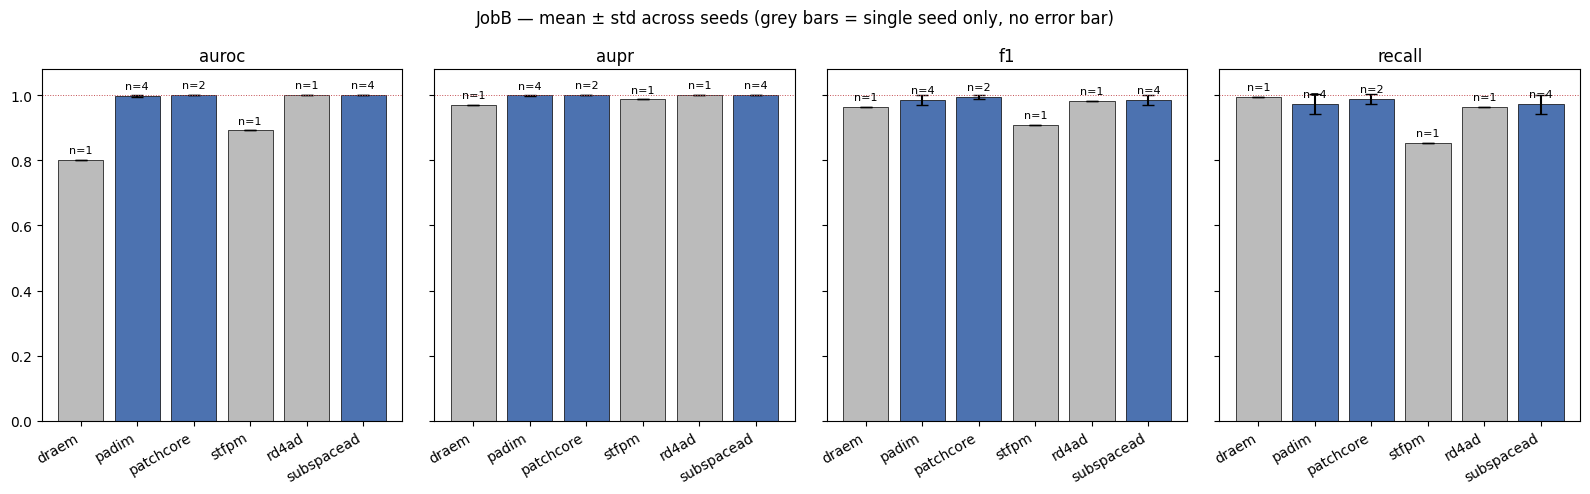

In [23]:
# §7.5 — visualization: mean ± std of f1 / auroc / recall / aupr per multi-seed model,
# with single-seed models drawn as a single point (no error bar).
if multi_seed_models or single_seed_models:
    plot_metrics = ["auroc", "aupr", "f1", "recall"]
    fig, axes = plt.subplots(1, len(plot_metrics), figsize=(4.0 * len(plot_metrics), 5), sharey=True)
    model_order = sorted(df["model"].unique())
    x = np.arange(len(model_order))
    for ax, metric in zip(axes, plot_metrics):
        means, stds, ns = [], [], []
        for m in model_order:
            vals = df.loc[df["model"] == m, metric].values
            means.append(np.mean(vals))
            stds.append(np.std(vals, ddof=1) if len(vals) > 1 else 0.0)
            ns.append(len(vals))
        colors = ["#4C72B0" if n >= 2 else "#bbbbbb" for n in ns]
        ax.bar(x, means, yerr=stds, capsize=4, color=colors, edgecolor="black", linewidth=0.5)
        for xi, mn, n in zip(x, means, ns):
            ax.text(xi, mn + 0.015, f"n={n}", ha="center", va="bottom", fontsize=8)
        ax.set_title(metric)
        ax.set_xticks(x)
        ax.set_xticklabels([m.replace("anomalib_", "") for m in model_order], rotation=30, ha="right")
        ax.set_ylim(0, 1.08)
        ax.axhline(1.0, color="#c44e52", lw=0.7, ls=":")
    fig.suptitle("JobB — mean ± std across seeds (grey bars = single seed only, no error bar)", fontsize=12)
    fig.tight_layout()
    plt.show()

In [24]:
# §7.6 — per-defect recall variance across seeds (multi-seed models only).
# Surfaces which defect classes are stable predictions vs which flip across splits.
rows = []
for _, r in df.iterrows():
    for d, v in (r["per_defect_recall"] or {}).items():
        rows.append({"model": r["model"], "seed": r["seed"], "defect": d, "recall": v})
long = pd.DataFrame(rows)
if not long.empty:
    pd_stats = (long[long["model"].isin(multi_seed_models)]
                  .groupby(["model", "defect"])["recall"]
                  .agg(["mean", "std", "min", "max", "count"])
                  .round(4))
    if not pd_stats.empty:
        print("=== per-defect recall — mean ± std across seeds ===")
        display(pd_stats)
    else:
        print("(no multi-seed models with per-defect recall)")

=== per-defect recall — mean ± std across seeds ===


mean     std     min  \
model              defect                                                   
anomalib_padim     Black spots                     0.9393  0.0021  0.9375   
                   Cleaning felt                   1.0000  0.0000  1.0000   
                   Degassing                       1.0000  0.0000  1.0000   
                   Pigment spill                   0.9618  0.0256  0.9474   
                   Scratch in extrusion direction  0.9729  0.0370  0.9202   
anomalib_patchcore Black spots                     0.8438  0.2210  0.6875   
                   Cleaning felt                   1.0000  0.0000  1.0000   
                   Degassing                       1.0000  0.0000  1.0000   
                   Pigment spill                   1.0000  0.0000  1.0000   
                   Scratch in extrusion direction  0.9943  0.0081  0.9886   
subspacead         Black spots                     1.0000  0.0000  1.0000   
                   Cleaning felt                   1.0000  0.0000  1.0000   
                   Degassing                       1.0000  0.0000  1.0000   
                   Pigment spill                   1.0000  0.0000  1.0000   
                   Scratch in extrusion direction  0.9658  0.0347  0.9174   

                                                      max  count  
model              defect                                         
anomalib_padim     Black spots                     0.9412      4  
                   Cleaning felt                   1.0000      4  
                   Degassing                       1.0000      4  
                   Pigment spill                   1.0000      4  
                   Scratch in extrusion direction  1.0000      4  
anomalib_patchcore Black spots                     1.0000      2  
                   Cleaning felt                   1.0000      2  
                   Degassing                       1.0000      2  
                   Pigment spill                   1.0000      2  
                   Scratch in extrusion direction  1.0000      2  
subspacead         Black spots                     1.0000      4  
                   Cleaning felt                   1.0000      4  
                   Degassing                       1.0000      4  
                   Pigment spill                   1.0000      4  
                   Scratch in extrusion direction  0.9972      4

**Reading §7:**

- **§7.1 coverage** tells you how much weight each per-model aggregate carries. Anything with
  `total_seeds < 3` should be reported as a point estimate, not a mean ± std.
- **§7.2 aggregates** is the table that goes into the thesis. Models with `count == 1` are
  excluded so a misleading `std=NaN` does not leak into the writeup.
- **§7.3 threshold CV** is the calibration-stability check. A coefficient of variation under
  ~0.05 means `val_f1` (or `val_quantile`) reliably picks the same operating point across
  splits. If CV is large for a model, the threshold mode for that model is fragile and the
  test-set numbers depend on which goods happen to be in val.
- **§7.4 saturation re-check** is the *coherence* answer. Metrics in `truly` saturated stayed at
  exactly 1.0 across *every* available seed — those are real but should still be retested with
  more seeds. Metrics in `sometimes` were saturated only at seed=42 — those are the
  single-seed-artifact numbers we suspected; they no longer support a `f1=1.0` claim.
- **§7.5 visualization** is the figure for the thesis. Grey bars (single-seed) communicate that
  the value is a point estimate, not an aggregate, without dropping the model entirely.
- **§7.6 per-defect variance** highlights which defect classes are *robustly* recognised. A class
  with `std≈0` across seeds is a stable prediction; a class with high std reveals that recognition
  depends on which examples landed in train vs test.

## §8 Engineering suggestions — what to look at next

Framed for the thesis goal (real-time visual defect detection that holds up on a single industrial
dataset). These are the questions the data above cannot fully answer on its own — flagging them so
the next iteration knows where to dig.

1. **Saturated metrics need a second test set.** Any model showing `auroc == 1.0` and `f1 ≥ 0.99`
   on a single 478-image test split should be retested against a *different* split (different
   `seed`, or a held-out batch from a later production day). This rules out the case where the
   train / test split happens to put all hard images on one side. The current `seed=42` is fixed —
   running with `seed=7, 17, 123` and reporting mean ± std would convert these single-shot numbers
   into something the thesis can defend.

2. **Threshold position is the silent failure mode.** §3.3 shows the calibrated threshold relative
   to the test score range. If a model's threshold sits below `min(test_score)` *and* above
   `min(val_score)` it just means "label everything as anomaly," which inflates recall to ≈1 while
   precision becomes whatever the prevalence allows. Treat any model where
   `frac_test_above_thr ∈ {<0.05, >0.95}` as effectively un-calibrated and rerun with
   `threshold_mode=val_quantile` for comparison.

3. **Generalization gap matters more than headline F1.** The `*_gap` columns in §1 are the ones to
   put in the thesis. A model with `val_f1=0.95` and `f1=0.96` is more trustworthy than one with
   `val_f1=0.90` and `f1=1.00`, even though the latter looks better on paper.

4. **Per-defect recall is where the deceuninck story gets interesting.** Support is heavily skewed
   (Scratch=353 vs Black-spots=16). A model that scores `recall=1.0` on Black-spots but `0.83` on
   Scratch is mostly being judged on Scratch. Plot recall against support and only celebrate models
   that hold the line on the high-support classes.

5. **Latency is reported as `ms_per_image` averaged over the full test set, single-image batch.**
   For a real-time deployment the relevant number is `p95_latency_ms` from `live_status_*.json`,
   not the mean — add it to the comparison table when the SLA discussion comes up.

6. **Fit-time delta vs JobA is the throughput story.** §6's `extra_models` block compares
   `fit_seconds` JobA-mean against JobB. If JobB ran ~3× faster than the JobA average for the same
   model, that is either (a) a smaller training set on Deceuninck (`train_samples=161` vs 200–500
   typical for Real-IAD), or (b) the run hit an early-stopping path. Worth checking the
   per-epoch loss curve before writing it up as a speedup.

7. **Cross-check with `live_status_*.json`.** The `fail_count` field is the count of frames the
   live consumer flagged. If `fail_count / frames_seen` differs from `1 - precision * recall / f1`
   it usually means the live pipeline applied a different threshold or skipped frames — a
   discrepancy here would invalidate any latency claim made from the same run.

8. **Persist a `manifest.csv`.** Right now run discovery is by directory name + timestamp. A flat
   manifest (`run_id, model, dataset, threshold_mode, seed, git_sha`) would make every future
   notebook one `pd.read_csv` away from the answer instead of re-walking the filesystem.